In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (Dense, Dropout,GlobalAveragePooling2D, BatchNormalization, Rescaling)
from tensorflow.keras.models import Sequential


In [2]:
# lode data set with google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/brain_tumor_BEST_95.keras')
print("Model loaded successfully!")

Model loaded successfully!


In [4]:
import os

dataset_path = "/content/drive/MyDrive/archive"

print(os.listdir(dataset_path))

['Testing', 'Training']


In [5]:
train_path = "/content/drive/MyDrive/archive/Training"

print(os.listdir(train_path))

['glioma', 'notumor', 'pituitary', 'meningioma']


In [6]:
# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/archive/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)



Found 1600 files belonging to 4 classes.


In [7]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/archive/Training",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/archive/Training",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)



Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


# Show image


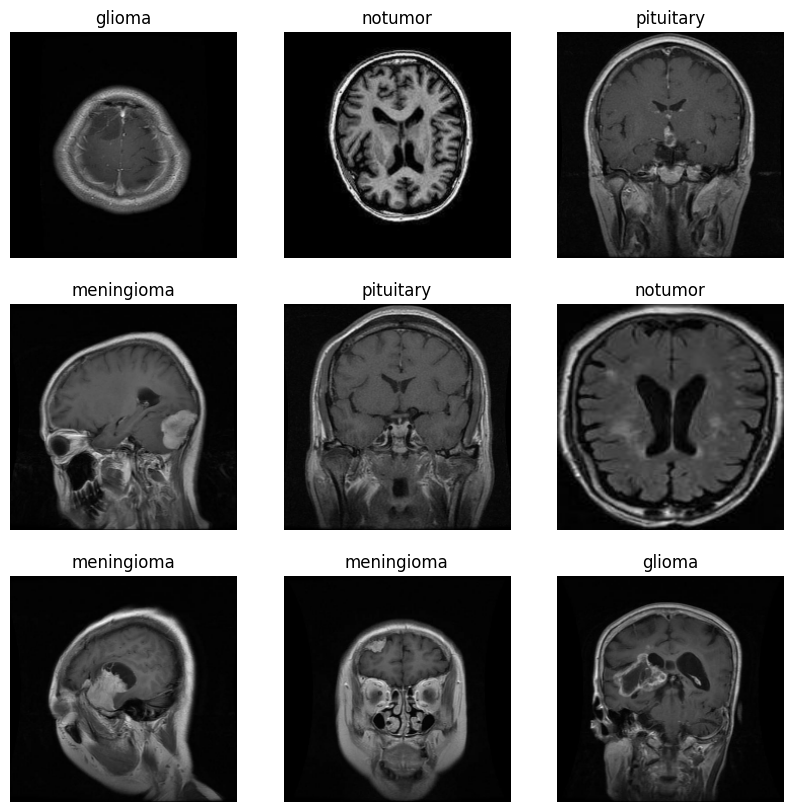

In [ ]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# Opencv

In [ ]:
import os

img_path = "/content/drive/MyDrive/archive/Training/glioma"

first_image = os.listdir(img_path)[0]

image = cv2.imread(
    os.path.join(img_path, first_image)
)

print(image.shape)

(512, 512, 3)


# opencv image show

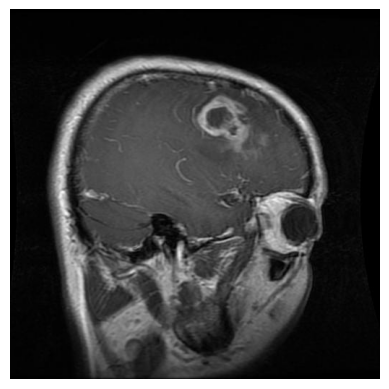

Resized shape: (224, 224, 3)
Normalized min/max: 0.0 0.9490196078431372


In [ ]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
resized = cv2.resize(image_rgb, (224, 224))
normalized = resized / 255.0

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

print("Resized shape:", resized.shape)
print("Normalized min/max:", normalized.min(), normalized.max())

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])



# Import pritrani model

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# model build

In [ ]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    data_augmentation,
    Rescaling(1./255),
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),

    # Hidden Layer 1
    Dense(200, activation='relu',
          kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(100, activation='relu',
          kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.2),

    # Output
    Dense(4, activation='softmax')
])


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       256,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,810,946 (25.98 MB)

 Trainable params: 2,134,968 (8.14 MB)

 Non-trainable params: 406,040 (1.55 MB)

 Optimizer params: 4,269,938 (16.29 MB)

# optmizer and learning rate

In [ ]:
from keras.optimizers import SGD, Adagrad, Adam, RMSprop,Adamax

adam = Adam(learning_rate=0.0005)
model.compile(
    optimizer=adam,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model

<Sequential name=sequential_1, built=False>

# Earlystop and lerning rate reduse setting and add chekpoint

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=5,
                  restore_best_weights=True,
                  verbose=1),


    ReduceLROnPlateau(factor=0.2,
                      patience=3,
                      verbose=1),


    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/checkpoint_best.keras',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

print("Training done!")

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6699 - loss: 0.9132
Epoch 1: val_loss improved from None to 0.57054, saving model to /content/drive/MyDrive/checkpoint_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/checkpoint_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 175ms/step - accuracy: 0.7580 - loss: 0.6971 - val_accuracy: 0.7955 - val_loss: 0.5705 - learning_rate: 5.0000e-04
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8341 - loss: 0.4788
Epoch 2: val_loss improved from 0.57054 to 0.47875, saving model to /content/drive/MyDrive/checkpoint_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/checkpoint_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 179ms/step - accuracy: 0.8435 - loss: 0.4685 - val_accuracy: 0.8304 - val_loss: 0.4787 - learning_rate: 5.0000e-04
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8733 - loss: 0.3881
Epoch 3: val_loss improved from 0.47875 to 0.39535, savin

In [ ]:
import os

print(os.path.exists('/content/drive/MyDrive/checkpoint_best.keras'))

True


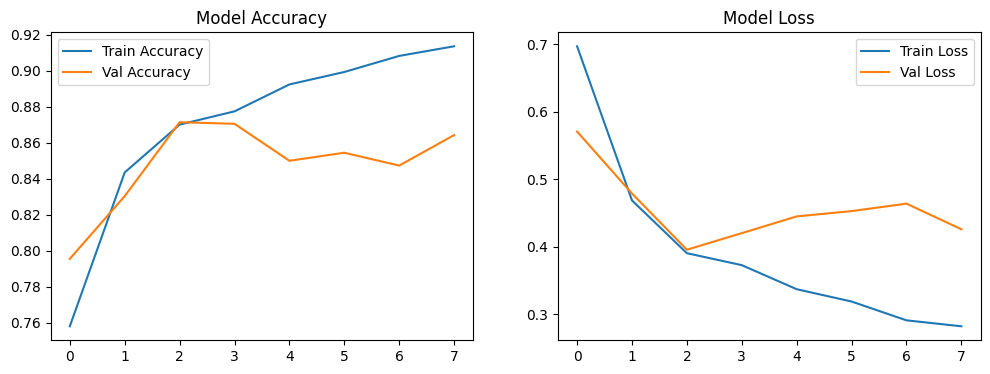

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_ds)
print(loss)
print(accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 435s 9s/step - accuracy: 0.8206 - loss: 0.6180
0.6179534792900085
0.8206250071525574


# Fine tuning

In [ ]:
# Model load
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/checkpoint_best.keras'
)


base_model = model.get_layer("mobilenetv2_1.00_224")
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

adam = Adam(learning_rate=0.0001)
model.compile(
    optimizer=adam,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8227 - loss: 0.5480
Epoch 1: val_loss did not improve from 0.39535
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 230ms/step - accuracy: 0.8516 - loss: 0.4517 - val_accuracy: 0.7830 - val_loss: 0.7814 - learning_rate: 1.0000e-04
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8976 - loss: 0.3153
Epoch 2: val_loss improved from 0.39535 to 0.38497, saving model to /content/drive/MyDrive/checkpoint_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/checkpoint_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 189ms/step - accuracy: 0.9071 - loss: 0.3019 - val_accuracy: 0.8705 - val_loss: 0.3850 - learning_rate: 1.0000e-04
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9332 - loss: 0.2321
Epoch 3: val_loss did not improve from 0.38497
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 182ms/step - accuracy: 0.9342 - loss: 0.2305 - val_accuracy: 0.8696 - val_loss: 0.4200 - learning_rate: 1.0000e-04
Epoch

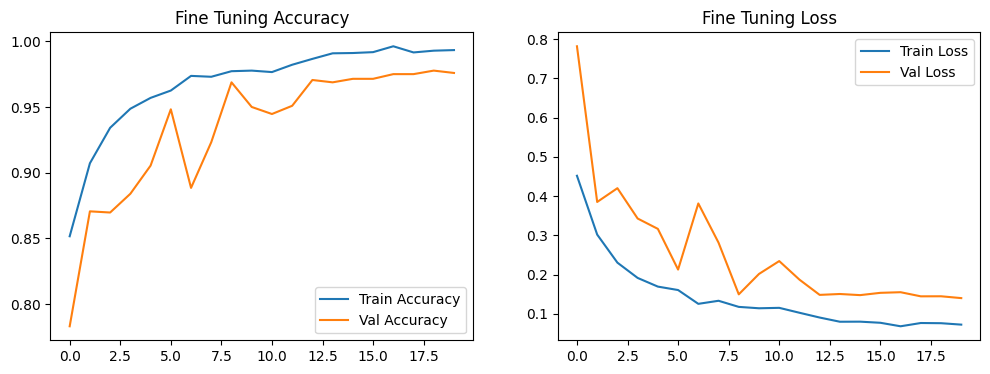

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Val Accuracy')
plt.title('Fine Tuning Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Val Loss')
plt.title('Fine Tuning Loss')
plt.legend()

plt.show()


In [ ]:
loss, accuracy = model.evaluate(test_ds)
print(loss)
print(accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.9519 - loss: 0.2861
0.28614574670791626
0.9518749713897705


In [10]:
model.save('/content/drive/MyDrive/brain_tumor_BEST_95.keras')


# Prediction + Grad-CAM Visualization

In [29]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Glioma image load
img_path = "/content/drive/MyDrive/archive/Testing/glioma"
test_img_path = os.path.join(img_path, os.listdir(img_path)[0])
image = cv2.imread(test_img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
resized = cv2.resize(image_rgb, (224, 224))

# Predict
img_array = tf.cast(np.expand_dims(resized, 0), tf.float32)
preds = model(img_array, training=False)
pred_index = np.argmax(preds[0].numpy())

print(f"Actual: glioma")
print(f"Predicted: {class_names[pred_index]}")
print(f"Confidence: {preds[0][pred_index]:.2f}")
print(f"All probs: {preds[0].numpy()}")

Actual: glioma
Predicted: glioma
Confidence: 1.00
All probs: [9.9966884e-01 3.7641694e-05 1.1315519e-04 1.8038398e-04]


# Grad-CAM Visualization

In [30]:
def get_gradcam_heatmap(model, image):
    img_array = tf.cast(
        np.expand_dims(image, axis=0),
        tf.float32
    )

    with tf.GradientTape() as tape:
        tape.watch(img_array)
        preds = model(img_array, training=False)
        pred_index = np.argmax(preds[0].numpy())
        loss = preds[:, pred_index]

    grads = tape.gradient(loss, img_array)
    grads = grads[0]
    heatmap = tf.reduce_mean(tf.abs(grads), axis=-1)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

heatmap = get_gradcam_heatmap(model, resized)
print(" Heatmap ready!")
print(f"Min: {heatmap.min():.3f}, Max: {heatmap.max():.3f}")

✅ Heatmap ready!
Min: 0.000, Max: 0.992


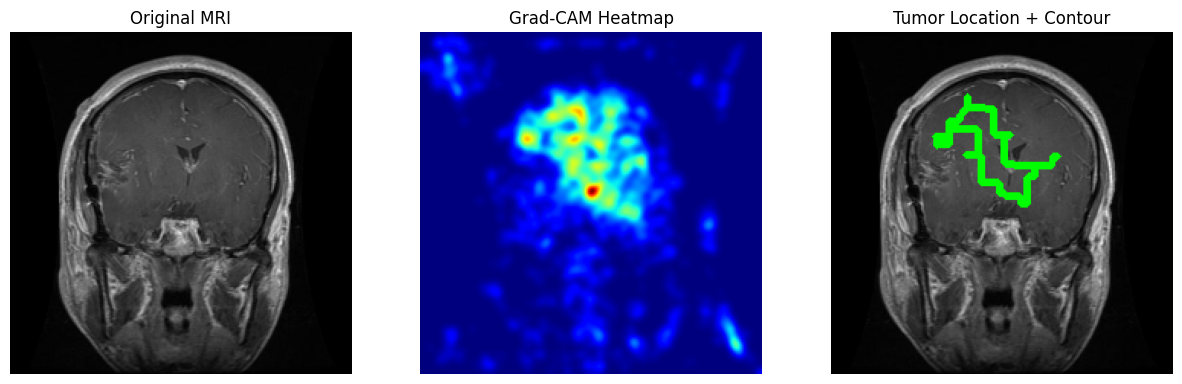

In [39]:
contour_img = resized.copy()

heatmap_uint8 = np.uint8(255 * heatmap_resized)
_, thresh = cv2.threshold(heatmap_uint8, 100, 255, cv2.THRESH_BINARY)  # 150 → 100

kernel = np.ones((15, 15), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Top 3 motte contours draw kar
contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
for cnt in contours_sorted[:3]:
    if cv2.contourArea(cnt) > 500:
        cv2.drawContours(contour_img, [cnt], -1, (0, 255, 0), 3)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(resized)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_smooth, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(contour_img)
plt.title("Tumor Location + Contour")
plt.axis("off")

plt.show()



# Confusion Matrix + Classification Report





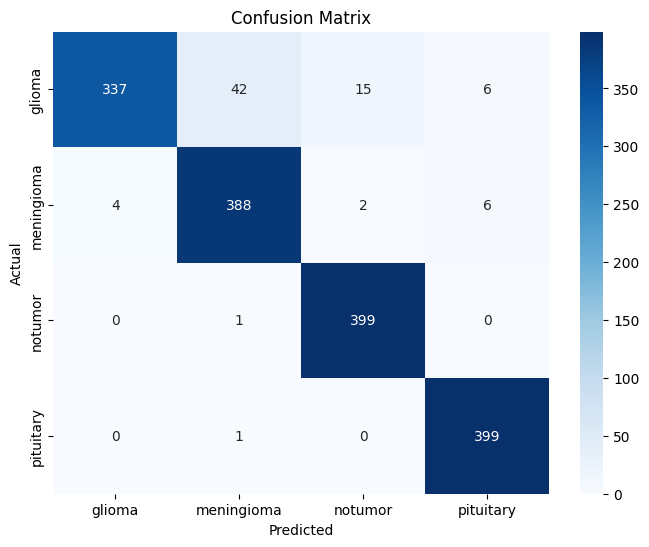

              precision    recall  f1-score   support

      glioma       0.99      0.84      0.91       400
  meningioma       0.90      0.97      0.93       400
     notumor       0.96      1.00      0.98       400
   pituitary       0.97      1.00      0.98       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model(images, training=False)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds.numpy(), axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

In [41]:
from google.colab import files

files.download('/content/drive/MyDrive/brain_tumor_BEST_95.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>